# 04 - Objective-gradient guidance during sampling

The class-minus-full correction uses fixed means and covariances. A
differentiable class objective can instead produce a direction that changes
with the current state. The generator remains frozen, but every active solver
evaluation now requires a backward pass through its denoised estimate.

This notebook asks two questions that a final target rate alone cannot answer:
when is the gradient informative, and what is lost when guidance becomes too
strong?

**Time convention:** `t=0` is noise and `t=1` is data.


In [1]:
import sys
from pathlib import Path

NOTES_DIR = Path.cwd()
if not (NOTES_DIR / "toy_notes.py").exists():
    NOTES_DIR = Path("notebooks/toy_data")
sys.path.insert(0, str(NOTES_DIR.resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from toy_notes import *
from notebook_views import *

SEED = 2026
set_seed(SEED)
device = choose_device()
print("device:", device)


device: cuda


In [2]:
model, losses, _ = load_or_train_model(device=device)
reference_data, reference_labels = sample_labeled_mixture(30000, device=device)
stats = estimate_gaussian_stats(reference_data, reference_labels)
TARGET_CLASS = 2


## 1. Why does an objective gradient provide a direction?

The three class Gaussians define `p(class | x)` in clean data space. During
sampling we first compute the model's denoised estimate `D_theta(x_t,t)`, then
differentiate `log p(target | D_theta)` with respect to the current state.

This is not a vector toward a preset coordinate. It is the gradient of a
class-level objective and changes with the state and time. The implementation
normalizes each gradient before adding it, so the direction comes from the
objective while the chosen guidance strength sets the update size. A higher
class score alone does not guarantee a realistic endpoint.

**Before you run:** On the contour plot, should a gradient arrow point along a
level curve or across it? What happens to the gradient near a local maximum?


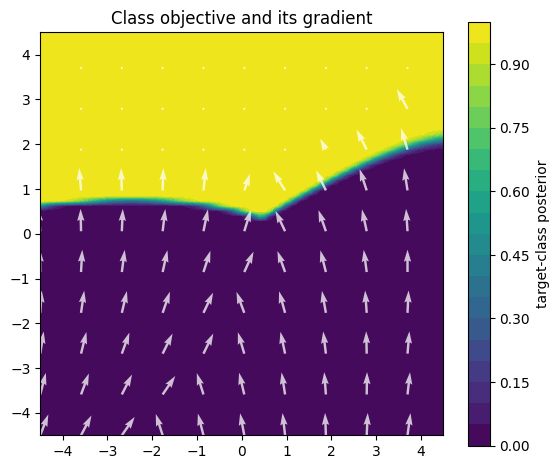

In [3]:
grid_1d = torch.linspace(-4.5, 4.5, 80, device=device)
gx, gy = torch.meshgrid(grid_1d, grid_1d, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1).requires_grad_(True)
log_posterior = class_log_probabilities(grid, stats).log_softmax(dim=1)[:, TARGET_CLASS]
posterior = log_posterior.exp()
gradient = torch.autograd.grad(log_posterior.sum(), grid)[0]

probability_image = posterior.reshape(gx.shape).detach().cpu()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
contour = ax.contourf(gx.cpu(), gy.cpu(), probability_image, levels=20, cmap="viridis")
arrow_points = grid.reshape(*gx.shape, 2)[::8, ::8].reshape(-1, 2)
arrow_gradient = gradient.reshape(*gx.shape, 2)[::8, ::8].reshape(-1, 2)
direction = arrow_gradient / arrow_gradient.norm(dim=1, keepdim=True).clamp_min(1e-6)
ax.quiver(
    arrow_points[:, 0].detach().cpu(), arrow_points[:, 1].detach().cpu(),
    direction[:, 0].detach().cpu(), direction[:, 1].detach().cpu(),
    color="white", alpha=0.75, scale=18,
)
fig.colorbar(contour, ax=ax, label="target-class posterior")
ax.set_title("Class objective and its gradient")
ax.set_aspect("equal")
plt.show()


## 2. When should the gradient be used?

At very high noise, the denoised estimate carries little class information. At
later times it is more informative, but an aggressive edit can damage a nearly
formed sample. We compare an early window, a broad middle/late window, and an
overly strong version of that broad window. Every method starts from the exact
same noise tensor.

**Before you run:** Predict which failure each setting is most likely to show:
an uninformative early signal, useful class movement, or reduced diversity from
excessive guidance.


In [4]:
def gradient_guided_velocity(strength, start, end):
    def velocity(t, x):
        gate = window_gate(t, start, end)[:, None]
        if gate.max() == 0:
            return model(t, x).detach()

        x_for_gradient = x.detach().requires_grad_(True)
        base = model(t, x_for_gradient)
        clean_estimate = x_for_gradient + (1 - t[:, None]) * base
        log_prob = class_log_probabilities(clean_estimate, stats).log_softmax(dim=1)
        objective = log_prob[:, TARGET_CLASS].sum()
        gradient = torch.autograd.grad(objective, x_for_gradient)[0]
        direction = gradient / gradient.norm(dim=1, keepdim=True).clamp_min(1e-6)
        return base.detach() + strength * gate * direction.detach()

    return velocity


In [5]:
set_seed(SEED + 40)
x0 = sample_base(1200, device=device)
target_reference = sample_class(1200, TARGET_CLASS, device=device)

methods = {
    "baseline": base_velocity(model),
    "class-minus-full": make_class_minus_full_velocity(
        model, stats, target_class=TARGET_CLASS, strength=1.6
    ),
    "gradient, early": gradient_guided_velocity(3.0, 0.02, 0.25),
    "gradient, middle/late": gradient_guided_velocity(3.0, 0.15, 0.92),
    "gradient, too strong": gradient_guided_velocity(6.0, 0.15, 0.92),
}

rows, paths = compare_steering_methods(
    methods, x0, target_reference, stats, target_class=TARGET_CLASS, steps=48,
)
gradient_table = pd.DataFrame(rows)


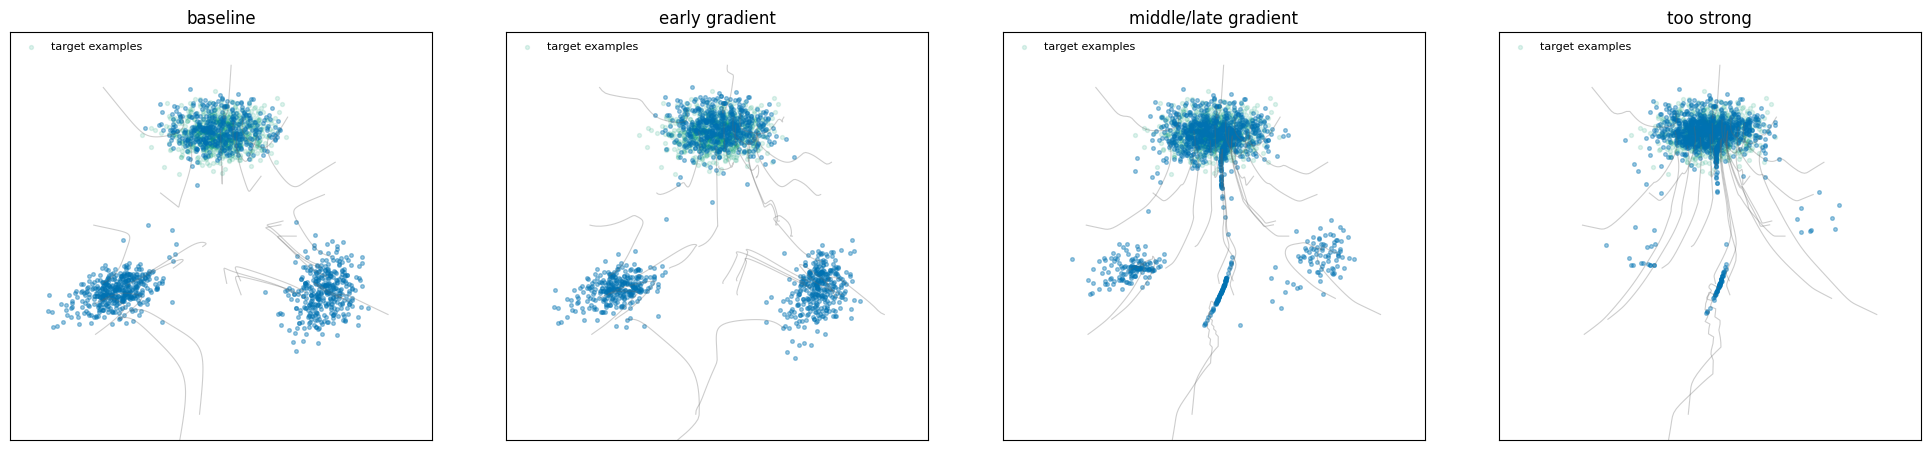

,method,target-class rate,empirical matching distance,diversity ratio,runtime / baseline
0,baseline,0.353,2.371,16.502,1.000
1,class-minus-full,0.641,1.264,12.021,3.931
2,"gradient, early",0.464,1.915,15.294,3.281
3,"gradient, middle/late",0.730,0.910,7.409,6.486
4,"gradient, too strong",0.932,0.291,2.500,8.092


In [6]:
plot_trajectory_comparison(
    {
        "baseline": paths["baseline"],
        "early gradient": paths["gradient, early"],
        "middle/late gradient": paths["gradient, middle/late"],
        "too strong": paths["gradient, too strong"],
    },
    target_reference=target_reference[:700],
)
plt.show()

relative = gradient_table.copy()
relative["runtime / baseline"] = relative["seconds"] / relative.loc[0, "seconds"]
display(relative[[
    "method", "target_rate", "target_wasserstein", "diversity_ratio",
    "runtime / baseline",
]].rename(columns={
    "target_rate": "target-class rate",
    "target_wasserstein": "empirical matching distance",
    "diversity_ratio": "diversity ratio",
}).round(3))


## Cost model

With Heun and 48 steps, the baseline makes 96 forward evaluations. Gradient
guidance can add a backward pass to most of those evaluations. The exact runtime
depends on hardware, but the computational distinction is structural:

| Method | Offline target data | Inference gradients | Main online work |
|---|---:|---:|---|
| Baseline | no | no | model forward passes |
| Class-minus-full PCA | yes | no | forwards + small matrix-vector operations |
| Gradient guidance | yes or external classifier | yes | forwards + backward passes |

The middle/late result should be read together with the early and overly strong
comparisons. A direction can be locally correct yet poorly timed, and stronger
control can trade away distributional fit or diversity.

**Change one thing:** In the methods cell, change only the end of the
middle/late window from `0.92` to `0.60`. Rerun the comparison and ask whether
stopping before samples are nearly formed changes the trade-off.

Objective-gradient guidance adapts to each state but pays for online
backpropagation. Notebook `05` asks whether class information already readable
inside the frozen velocity network can support a forward-only intervention.
